# Customer Segmentation with K-Means Clustering

K-Means is an unsupervised machine learning algorithm that groups similar data points into **K** clusters based on their features. It's used when the dataset has no labels.

**Dataset:** *Mall Customer Segmentation* (Kaggle: `vjchoudhary7/customer-segmentation-tutorial-in-python`) — 200 mall customers with `CustomerID`, `Gender`, `Age`, `Annual Income (k$)` and `Spending Score (1-100)`.

**Goal:** segment customers by their **annual income** and **spending score** so the mall can target marketing at distinct groups (e.g. high-income/high-spenders vs. high-income/low-spenders).

## Common K-Means Use Cases

<table style="margin-left:0; text-align:left">
<thead>
<tr><th style="text-align:left">Use Case</th><th style="text-align:left">Industry</th><th style="text-align:left">Example</th></tr>
</thead>
<tbody>
<tr><td style="text-align:left">Customer Segmentation</td><td style="text-align:left">Retail, E-commerce</td><td style="text-align:left">Group customers by spending habits</td></tr>
<tr><td style="text-align:left">Market Segmentation</td><td style="text-align:left">Marketing</td><td style="text-align:left">Identify different customer personas</td></tr>
<tr><td style="text-align:left">Recommendation Systems</td><td style="text-align:left">Streaming, Shopping</td><td style="text-align:left">Group users with similar interests</td></tr>
<tr><td style="text-align:left">Fraud Detection (Preprocessing)</td><td style="text-align:left">Banking</td><td style="text-align:left">Find unusual transactions far from clusters</td></tr>
<tr><td style="text-align:left">Image Compression</td><td style="text-align:left">Computer Vision</td><td style="text-align:left">Reduce image colors from millions to a few clusters</td></tr>
<tr><td style="text-align:left">Document Clustering</td><td style="text-align:left">NLP</td><td style="text-align:left">Group similar news articles</td></tr>
<tr><td style="text-align:left">Social Media Analysis</td><td style="text-align:left">Social Media</td><td style="text-align:left">Cluster users by behavior</td></tr>
<tr><td style="text-align:left">Network Traffic Analysis</td><td style="text-align:left">Cybersecurity</td><td style="text-align:left">Identify normal traffic patterns</td></tr>
<tr><td style="text-align:left">Sales Territory Planning</td><td style="text-align:left">Sales</td><td style="text-align:left">Group nearby customers geographically</td></tr>
<tr><td style="text-align:left">Healthcare Patient Segmentation</td><td style="text-align:left">Healthcare</td><td style="text-align:left">Group patients with similar symptoms</td></tr>
<tr><td style="text-align:left">Student Performance Analysis</td><td style="text-align:left">Education</td><td style="text-align:left">Categorize students by learning patterns</td></tr>
<tr><td style="text-align:left">Real Estate Analysis</td><td style="text-align:left">Real Estate</td><td style="text-align:left">Group houses by location and price</td></tr>
<tr><td style="text-align:left">Inventory Management</td><td style="text-align:left">Supply Chain</td><td style="text-align:left">Cluster products by demand patterns</td></tr>
<tr><td style="text-align:left">Sensor Data Analysis</td><td style="text-align:left">IoT</td><td style="text-align:left">Detect operating states of machines</td></tr>
<tr><td style="text-align:left">Gene Expression Analysis</td><td style="text-align:left">Bioinformatics</td><td style="text-align:left">Group similar genes</td></tr>
</tbody>
</table>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Download latest version of the Mall Customer Segmentation dataset
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
print("Path to dataset files:", path)

df = pd.read_csv(f"{path}/Mall_Customers.csv")

# Rename to short, code-friendly column names
df = df.rename(columns={
    "Annual Income (k$)":     "AnnualIncome",
    "Spending Score (1-100)": "SpendingScore",
})

print("Shape:", df.shape)
df.head()

Path to dataset files: C:\Users\91720\.cache\kagglehub\datasets\vjchoudhary7\customer-segmentation-tutorial-in-python\versions\1
Shape: (200, 5)


,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
X = df[["AnnualIncome", "SpendingScore"]]

In [4]:
# K-Means uses Euclidean distance, so a feature with a larger range would
# dominate the clustering. Standardize each feature to mean 0, std 1 so
# AnnualIncome and SpendingScore contribute equally.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# fit_transform returns a NumPy array; wrap it in a DataFrame just to inspect.
# Each column should now have mean ~0 and std ~1.
pd.DataFrame(X_scaled, columns=X.columns).head()

,AnnualIncome,SpendingScore
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


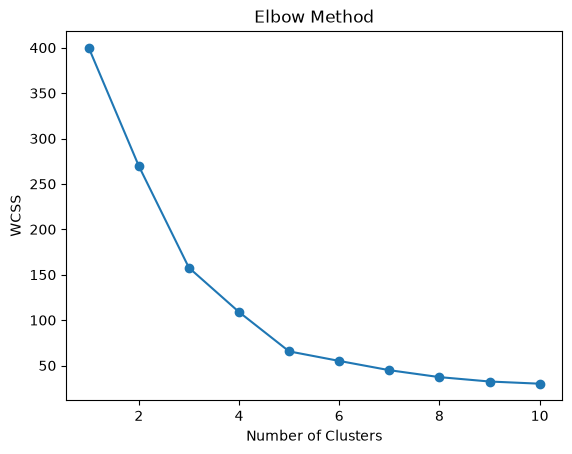

In [6]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [7]:
# Elbow plot above bends at k=5 for this dataset
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

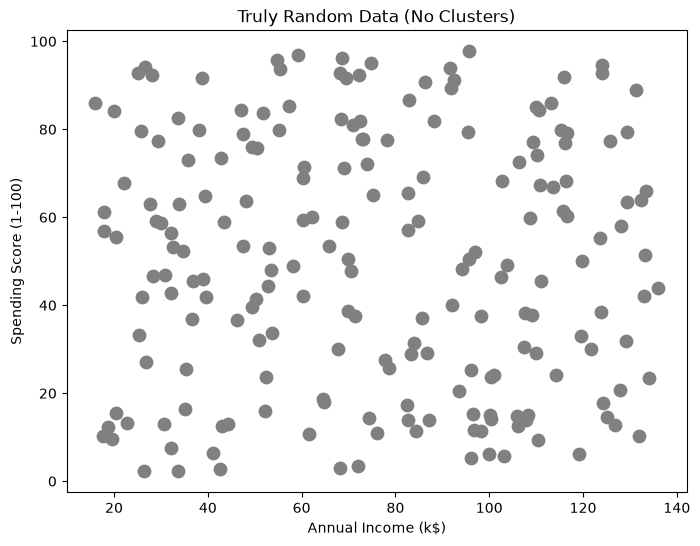

In [11]:
rng = np.random.default_rng(42)
n = len(df)

rand_income = rng.uniform(df["AnnualIncome"].min(), df["AnnualIncome"].max(), n)
rand_score  = rng.uniform(df["SpendingScore"].min(), df["SpendingScore"].max(), n)

plt.figure(figsize=(8, 6))
plt.scatter(rand_income, rand_score, c="gray", s=80)
plt.title("Truly Random Data (No Clusters)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

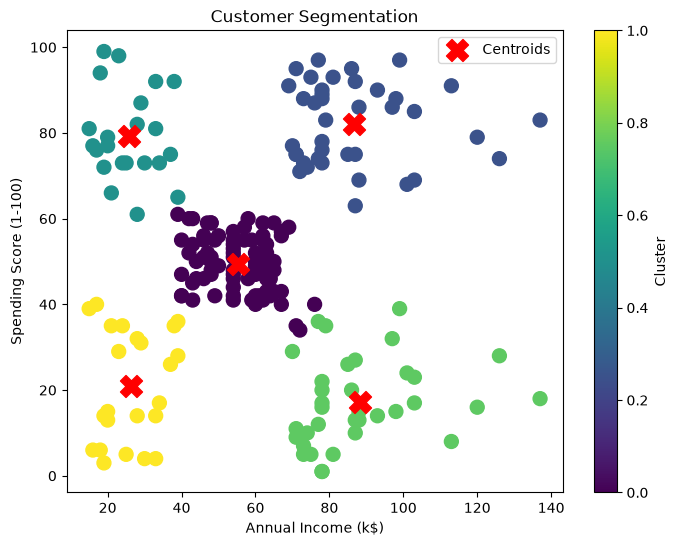

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["AnnualIncome"],
    df["SpendingScore"],
    c=df["Cluster"],
    cmap="viridis",
    s=100
)

# Mark the cluster centres (inverse-transform back to original units)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation")
plt.legend()

plt.colorbar(label="Cluster")
plt.show()

In [13]:
print("\nCluster Summary:")
print(
    df.groupby("Cluster")
      [["AnnualIncome","SpendingScore"]]
      .mean()
)


Cluster Summary:
         AnnualIncome  SpendingScore
Cluster                             
0           55.296296      49.518519
1           86.538462      82.128205
2           25.727273      79.363636
3           88.200000      17.114286
4           26.304348      20.913043
